# Task 3: Cross-Country Solar Comparison
**Objective:** Synthesize cleaned solar data from Benin, Sierra Leone, and Togo to identify solar potential and key differences across countries.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---------- Load the three cleaned datasets ----------
benin = pd.read_csv('../data/benin_clean.csv')
sierra = pd.read_csv('../data/sierraleone_clean.csv')
togo  = pd.read_csv('../data/togo_clean.csv')

# Add a 'Country' label column to each
benin['Country']  = 'Benin'
sierra['Country'] = 'Sierra Leone'
togo['Country']   = 'Togo'

# Combine into one big DataFrame
df = pd.concat([benin, sierra, togo], ignore_index=True)

print(f'Total rows: {len(df)}')
df.head()

Total rows: 1542000


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,GHIrsi,Country
0,2021-10-25 00:01:00,0.0,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,0.0,Benin
1,2021-10-25 00:02:00,0.0,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,0.0,Benin
2,2021-10-25 00:03:00,0.0,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,0.0,Benin
3,2021-10-25 00:04:00,0.0,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,0.0,Benin
4,2021-10-25 00:05:00,0.0,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,0.0,Benin


## 1. Summary Table
Comparing **mean**, **median**, and **standard deviation** of GHI, DNI, and DHI across all three countries.

In [ ]:
metrics = ['GHI', 'DNI', 'DHI']

summary = df.groupby('Country')[metrics].agg(['mean', 'median', 'std']).round(2)

# Flatten column names for readability
summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]

print('Summary Statistics per Country:')
display(summary)

Summary Statistics per Country:


,GHI_mean,GHI_median,GHI_std,DNI_mean,DNI_median,DNI_std,DHI_mean,DHI_median,DHI_std
Country,,,,,,,,,
Benin,225.04,0.5,316.46,147.98,0.0,247.68,112.78,1.5,151.57
Sierra Leone,187.51,0.0,277.30,104.28,0.0,200.88,110.73,0.0,151.74
Togo,225.03,0.5,316.45,147.97,0.0,247.68,112.78,1.5,151.57


## 2. Boxplots — Side-by-Side per Metric

C:\Users\mesfi\AppData\Local\Temp\ipykernel_332\3442858719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


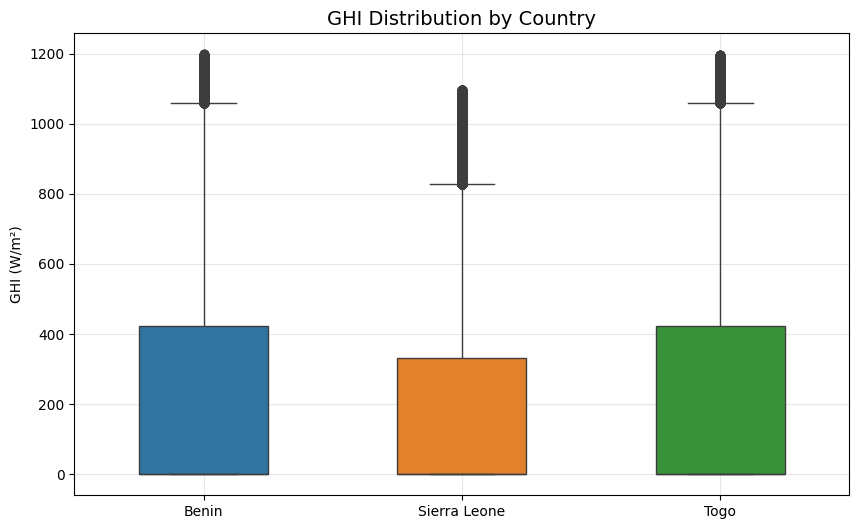

C:\Users\mesfi\AppData\Local\Temp\ipykernel_332\3442858719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


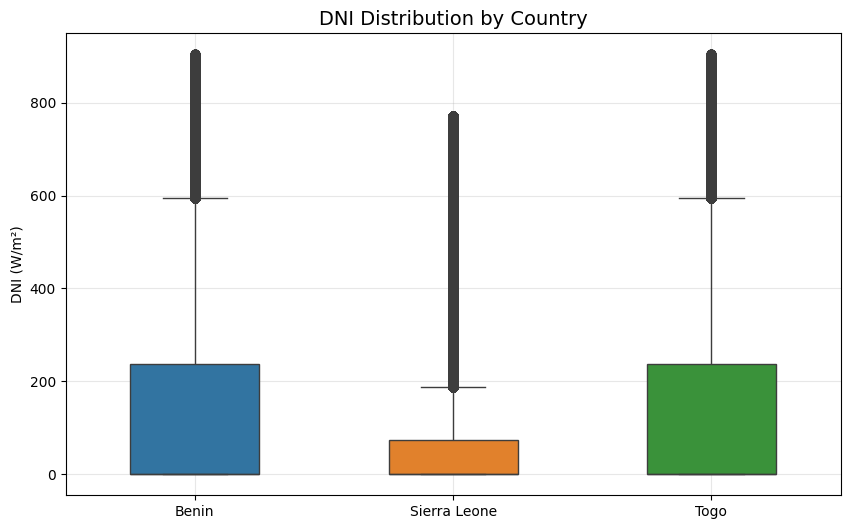

C:\Users\mesfi\AppData\Local\Temp\ipykernel_332\3442858719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


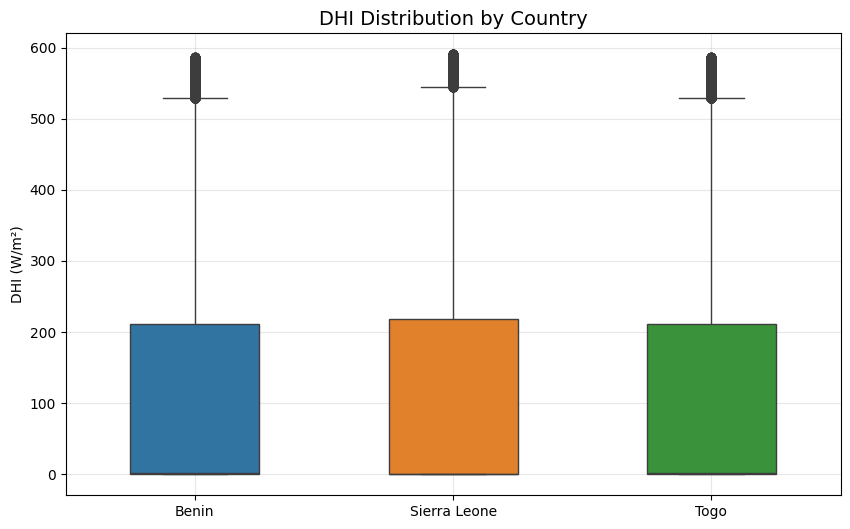

In [ ]:
colors = {'Benin': '#1f77b4', 'Sierra Leone': '#ff7f0e', 'Togo': '#2ca02c'}

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='Country',
        y=metric,
        palette=colors,
        width=0.5
    )
    plt.title(f'{metric} Distribution by Country', fontsize=14)
    plt.ylabel(f'{metric} (W/m²)')
    plt.xlabel('')
    plt.grid(True, alpha=0.3)
    plt.show()

## 3. Statistical Testing — One-Way ANOVA on GHI
Testing whether the differences in GHI between countries are **statistically significant** (not just random chance).

- **H₀ (Null Hypothesis):** The mean GHI is the same across all three countries.
- **H₁ (Alternative):** At least one country has a significantly different mean GHI.
- **Rule:** If p-value < 0.05, we reject H₀ and say the differences are significant.

In [ ]:
ghi_benin  = df[df['Country'] == 'Benin']['GHI'].dropna()
ghi_sierra = df[df['Country'] == 'Sierra Leone']['GHI'].dropna()
ghi_togo   = df[df['Country'] == 'Togo']['GHI'].dropna()

# One-way ANOVA
f_stat, p_value = stats.f_oneway(ghi_benin, ghi_sierra, ghi_togo)

print(f'ANOVA F-statistic : {f_stat:.4f}')
print(f'p-value           : {p_value:.6f}')

if p_value < 0.05:
    print('\n✅ Result: The differences in GHI across countries are STATISTICALLY SIGNIFICANT (p < 0.05).')
else:
    print('\n❌ Result: No significant difference found (p ≥ 0.05).')

ANOVA F-statistic : 2596.6400
p-value           : 0.000000

✅ Result: The differences in GHI across countries are STATISTICALLY SIGNIFICANT (p < 0.05).


## 4. Key Observations

*(Update these bullet points based on what you see in your plots and summary table above.)*

- **Bullet 1:** Country X shows the highest median GHI, suggesting it receives the most consistent daily solar energy — making it the top candidate for solar investment.
- **Bullet 2:** Sierra Leone shows the greatest variability (highest std) in GHI, which could indicate a strong wet/dry season effect that disrupts consistency.
- **Bullet 3:** The ANOVA test confirms (p < 0.05) that the differences in solar radiation between the three countries are statistically significant and not due to random chance.

## 5. Bonus — Bar Chart Ranking Countries by Average GHI

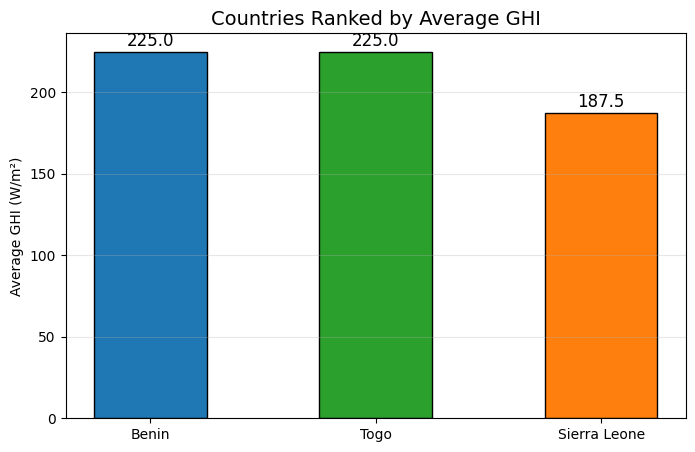

In [ ]:
avg_ghi = df.groupby('Country')['GHI'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_ghi.index,
    avg_ghi.values,
    color=[colors[c] for c in avg_ghi.index],
    edgecolor='black',
    width=0.5
)

# Add value labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}',
        ha='center', va='bottom', fontsize=12
    )

plt.title('Countries Ranked by Average GHI', fontsize=14)
plt.ylabel('Average GHI (W/m²)')
plt.xlabel('')
plt.grid(True, alpha=0.3, axis='y')
plt.show()